# Initial Installation Requirements

In [1]:
# necessary installations
!pip install -q pandas numpy gdown matplotlib scipy plotly tqdm scikit-learn opencv-python

# 1A: Code & Answers

In [2]:
# main imports
import pandas as pd
import numpy as np

In [3]:
# import CSV and dictionary
import gdown
csv_id = '1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH'
dict_id = '1GKbh50b-NexKtv-47-y4VP1kklBIvX5p'

gdown.download(id=csv_id,output='co_occur.csv')
gdown.download(id=dict_id,output='dictionary.txt')

Downloading...
From (original): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH
From (redirected): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH&confirm=t&uuid=02804b92-b7a6-44b1-b453-1beba2bbc1d7
To: C:\Users\ayaan\OneDrive\Desktop\VS Code Parent\svd-project\co_occur.csv
100%|██████████| 281M/281M [00:09<00:00, 29.0MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1GKbh50b-NexKtv-47-y4VP1kklBIvX5p
To: C:\Users\ayaan\OneDrive\Desktop\VS Code Parent\svd-project\dictionary.txt
100%|██████████| 79.3k/79.3k [00:00<00:00, 1.00MB/s]


'dictionary.txt'

In [4]:
# import matrix and dictionary
M = pd.read_csv('co_occur.csv',header=None).values

with open('dictionary.txt','r') as d:
    dictionary = d.read().splitlines()

print("Matrix shape:", M.shape)
print("First 10 words in dictionary:", dictionary[:10])

Matrix shape: (10000, 10000)
First 10 words in dictionary: ['the', 'of', 'in', 'and', 'to', 'was', 'is', 'for', 'on', 'as']


# 1B: Code & Answers

In [5]:
# import
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

# normalize the matrix
M_norm = np.log(1 + M)

# get SVDs in descending order
U, S, V_T = svds(M_norm, k=100) #ascending order so we need to reverse
U = U[:, ::-1] #reverse columns
S = S[::-1] #reverse array
V_T = V_T[::-1, :] #reverse rows

# save the SVD
np.savez('rank-100-svd',U=U,S=S,V_T=V_T)

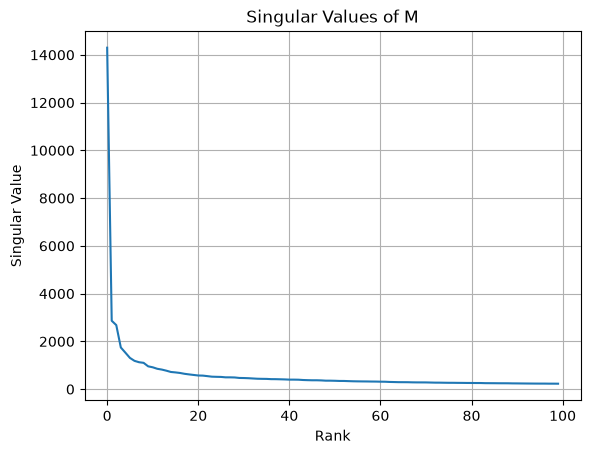

In [6]:
# plot the singular values
plt.plot(S)
plt.title('Singular Values of M')
plt.xlabel('Rank')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

### Answer to Question 1B:

M seems to be a low-rank matrix, as the singular values drop of significantly after the first few ranks. We can see this from the graph, where the singular values rapidly decrease, reaching under 2000 before rank 5.

# 1C: Code & Answers

In [7]:
# iterate through the 10 most important singular vectors
for i in range(10):
    # assign the singular vector
    v_i = U[:, i]
    v_indices = np.argsort(v_i)

    # take the 10 most positive and negative values
    pos_idx = v_indices[::-1][:10]
    neg_idx = v_indices[:10]
    pos_words = [dictionary[idx] for idx in pos_idx]
    neg_words = [dictionary[idx] for idx in neg_idx]
    
    print(f"Rank {i} --> Singular Value = {S[i]}")
    print("Most Positive Words:", pos_words)
    print("Most Negative Words:", neg_words)

    print()

Rank 0 --> Singular Value = 14299.743065022343
Most Positive Words: ['gmina', 'insee', 'householder', 'increment', 'peakposition', 'midst', 'outskirts', 'iucn', 'voivodeship', 'subtropical']
Most Negative Words: ['the', 'and', 'of', 'in', 'to', 'for', 'as', 'is', 'with', 'was']

Rank 1 --> Singular Value = 2864.8156015105537
Most Positive Words: ['innings', 'tournaments', 'leagues', 'constituency', 'medals', 'locomotives', 'households', 'manga', 'billboard', 'theaters']
Most Negative Words: ['the', 'and', 'of', 'in', 'to', 'for', 'with', 'as', 'by', 'is']

Rank 2 --> Singular Value = 2682.6537863979934
Most Positive Words: ['born', 'john', 'james', 'david', 'robert', 'william', 'jr', 'george', 'thomas', 'michael']
Most Negative Words: ['specific', 'any', 'data', 'provide', 'these', 'certain', 'different', 'systems', 'its', 'use']

Rank 3 --> Singular Value = 1745.5549202096247
Most Positive Words: ['you', 'album', 'love', 'me', 'my', 'song', 'episode', 'your', 'vocals', 'baby']
Most Ne

### Answer to Question 1C:

#### 5 Interpretable Singular Vectors
- **Rank 1 Singular Vector**
  - Most Positive Words: `['innings', 'tournaments', 'leagues', 'constituency', 'medals', 'locomotives', 'households', 'manga', 'billboard', 'theaters']`
  - Most Negative Words: `['the', 'and', 'of', 'in', 'to', 'for', 'with', 'as', 'by', 'is']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with very specific niches (like sports, entertainment, etc.), which have very positive values, with vocabulary that is very generic (function words liks `the` and `of`), which have very negative values.*
- **Rank 2 Singular Vector**
  - Most Positive Words: `['born', 'john', 'james', 'david', 'robert', 'william', 'jr', 'george', 'thomas', 'michael']`
  - Most Negative Words: `['specific', 'any', 'data', 'provide', 'these', 'certain', 'different', 'systems', 'its', 'use']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with names (like `john` and `jr`), which have very positive values, with vocabulary more associated with research and/or formal wording (like `data` and `systems`), which have very negative values.*
- **Rank 4 Singular Vector**
  - Most Positive Words: `['jpg', 'km', 'located', 'near', 'road', 'river', 'lake', 'route', 'station', 'mountain']`
  - Most Negative Words: `['political', 'social', 'religious', 'law', 'legal', 'policy', 'rights', 'government', 'minister', 'jewish']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with location-based or physical ideas (like `km` or `lake`), which have very positive values, with vocabulary associated with governance, religion, or artificial ideas (like `religious` or `law`), which have very negative values.*
- **Rank 5 Singular Vector**
  - Most Positive Words: `['troops', 'him', 'killed', 'soldiers', 'they', 'them', 'were', 'had', 'emperor', 'attacked']`
  - Most Negative Words: `['digital', 'science', 'software', 'technology', 'engineering', 'computer', 'research', 'online', 'web', 'electronic']`
  - Semantic/Syntatic Structure: *The vector contrasts vocabulary associated with war (like `troops` and `killed`), which have very positive values, with vocabulary more associated with technology (like `digital` and `software`), which have very negative values.*
- **Rank 7 Singular Vector**
  - Most Positive Words: `['took', 'gave', 'brought', 'led', 'joined', 'served', 'moved', 'came', 'became', 'entered']`
  - Most Negative Words: `['him', 'them', 'it', 'himself', 'her', 'students', 'who', 'government', 'people', 'players']`
  - Semantic/Syntatic Structure: *The vector contrasts past-tense action verbs (like `took` and `led`), which have very positive values, with pronouns (like `him` or `it`), which have very negative values.*


#### Why not all of the singular vectors have easy-to-interpret semantics:
I think that not all the singular vectors have easy-to-interpret semantics because they are solely there to explain the variance in the data. Since they do not specifically look for semantic coherence (which humans look for, as we tend to look for words that would work well together logically), there were some cases where the vectors were used to explain variance, but we couldn't really interpret why, because it wasn't explaining the semantic coherence that we look for. An example of this was the `Rank 0 Singular Vector`, for which the most positive words (`['the', 'and', 'of', 'in', 'to', 'for', 'as', 'is', 'with', 'was']`) were very generic function words, but the most negative words were seemingly random words that we don't write with a lot (`['gmina', 'insee', 'householder', 'increment', 'peakposition', 'midst', 'outskirts', 'iucn', 'voivodeship', 'subtropical']`). Other than that, there was not really any relationship between the words, causing difficulty in interpretation, despite the vector well explaining the variance.

# 1D: Code & Answers

In [8]:
# normalize each row of U
for i in range(len(U)):
    norm = np.linalg.norm(U[i])
    U[i] = U[i] / norm

In [9]:
# function to find embeddings of specific words
def find_embedding(word):
    idx = dictionary.index(word)
    return U[idx]

# define vector v
v1 = find_embedding("woman")
v2 = find_embedding("man")
v = v1 - v2

## 1D (i)

In [10]:
# gets the scalar projection of a given word on a given vector
def get_projection(word, vector):
    embedding = find_embedding(word)
    dotP = np.dot(embedding, vector)
    mag = np.linalg.norm(vector)
    return dotP / mag

# get the projections for the given words
words = ['boy','girl','brother','sister','king','queen','he','she','john','mary','wall','tree']
projections = [get_projection(word, v) for word in words]

In [11]:
# let plots render in jupyter
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [12]:
# import
import plotly.express as px

# create the plot & fix UI
fig = px.scatter(x=projections, y=np.zeros_like(projections), text=words)
fig.update_traces(textposition="top center")
fig.update_yaxes(visible=False)
fig.update_layout(showlegend=False, height=200)

# draw the plot
fig.show()

### Answer to 1D (i)

It seems like the words more associated with `men` are more negative, and the words more associated with `women` are more positive, as expected. We can see that the neutral word `tree` stayed in the middle, due to its gender neutrality, while words like `girl` and `mary` (which are more feminine) are positive and words like `boy` and `john` (which are more masculine) are negative. This aligns with the original vector in which `women` was the positive and `men` was negative (v = v1 - v2).

## 1D (ii)

In [13]:
# import
import plotly.express as px

# get the projections for the given words
words = ['math','matrix','history','nurse','doctor','pilot','teacher','engineer','science','arts','literature','bob','alice']
projections = [get_projection(word, v) for word in words]

# create the plot & fix UI
fig = px.scatter(x=projections, y=np.zeros_like(projections), text=words)
fig.update_traces(textposition="top center")
fig.update_yaxes(visible=False)
fig.update_layout(showlegend=False, height=200)

# draw the plot
fig.show()

### Answer to 1D (ii)

It seems that the vector space affirms long-standing stereotypes of certain professions and/or other things that correlate to men or women. We can see that `engineer` is heavily negative, while `nurse` is heavily positive, despite both jobs being open to both genders. Additionally, words like `math`, `doctor`, and `pilot` are more masculine, while words like `teacher` and `arts` are more feminine, indicating a bias to long-standing stereotypes that may not really show the true correlation between how words should be used. This could be an issue, as if new systems use these embeddings to search for job candidates, these stereotypes will be further reaffirmed, despite an overarching societal goal of gender equality, especially in the workplace.

### Answer to 1D (iii)

One way to help mitigate the problem discussed in part 1D (ii) is to identify and project gender neutral words onto a plane that is orthogonal from gender-based words. This would remove any gender-bias in the embeddings for these words, causing them to have a projection of `0` on vector v.

# 1E: Code & Answers

In [14]:
# import
import plotly.express as px

# create vector v
v1 = find_embedding("strong")
v2 = find_embedding("weak")
v = v1 - v2

# get the projections for the given words
words = ['paper','glass','wood','metal']
projections = [get_projection(word, v) for word in words]

# create the plot & fix UI
fig = px.scatter(x=projections, y=np.zeros_like(projections), text=words)
fig.update_traces(textposition="top center")
fig.update_yaxes(visible=False)
fig.update_layout(showlegend=False, height=200)

# draw the plot
fig.show()

# 1F: Code & Answers

### Answer to 1F (i)

In [15]:
# run cos_similarity for all words
def sim_values(val, exclude=None):
    # check if val is a string or vector
    if isinstance(val, str):
        v1 = find_embedding(val)
    else:
        v1 = val

    # get the cosine similarities in one matrix
    sim_vector = U @ v1
    
    if exclude is not None:
        for w in exclude:
            sim_vector[dictionary.index(w)] = -np.inf
            
    return sim_vector

# get the k most similar words
def most_similar(val, k, exclude=None):
    values = sim_values(val, exclude)
    sim_idx = np.argsort(values)
    top_idx = sim_idx[::-1][:k]
    top_10 = [dictionary[idx] for idx in top_idx]
    return top_10

In [16]:
# test for the word "stanford"
sim_stanford = most_similar("stanford", 10)
sim_stanford_excluded = most_similar("stanford", 10, exclude=["stanford"])
print("Most similar words to \"stanford\":")
print(sim_stanford,"\n")
print("Most similar words to \"stanford\" excluding \"stanford\":")
print(sim_stanford_excluded)

Most similar words to "stanford":
['stanford', 'cornell', 'harvard', 'ucla', 'yale', 'princeton', 'penn', 'tech', 'auburn', 'mit'] 

Most similar words to "stanford" excluding "stanford":
['cornell', 'harvard', 'ucla', 'yale', 'princeton', 'penn', 'tech', 'auburn', 'mit', 'berkeley']


### Answer to 1F (ii)

In [17]:
import gdown
analogies_id = '1xP3EXqTPqpZJqNHnrXfdq_mSbPPo7E8v'
gdown.download(id=analogies_id,output='analogy_task.txt')

Downloading...
From: https://drive.google.com/uc?id=1xP3EXqTPqpZJqNHnrXfdq_mSbPPo7E8v
To: C:\Users\ayaan\OneDrive\Desktop\VS Code Parent\svd-project\analogy_task.txt
100%|██████████| 165k/165k [00:00<00:00, 1.62MB/s]


'analogy_task.txt'

In [18]:
# get the word for the analogy
def analogy_value(a1, a2, b1):
    v_a1 = find_embedding(a1)
    v_a2 = find_embedding(a2)
    v_b1 = find_embedding(b1)
    
    return most_similar(v_a2 - v_a1 + v_b1, 1, exclude = [a1, a2, b1])[0]

In [19]:
# test analogy "Man is to woman as king is to _____"
ana_val = analogy_value("man", "woman", "king")
print(f"Man is to woman as king is to \033[1m{ana_val}\033[0m.")

Man is to woman as king is to queen.


In [20]:
# download the analogy_task.txt
with open('analogy_task.txt','r') as a:
    analogies = [line.split() for line in a.read().splitlines()]

print("First analogy task:", analogies[0])

First analogy task: ['athens', 'greece', 'bangkok', 'thailand']


In [21]:
# progress bar
from tqdm import tqdm

# run the analogy tasks and record the percentage correct
ana_correct = 0
ana_total = len(analogies)
ana_preds = []

for task in tqdm(analogies):
    pred = analogy_value(task[0], task[1], task[2])
    ans = task[3]
    if(pred == ans):
        ana_correct += 1
        ana_preds.append([1, pred, ans])
    else:
        ana_preds.append([0, pred, ans])

print(f"Percent of correct analogy predictions: {ana_correct / ana_total * 100}%")

100%|██████████| 5585/5585 [00:08<00:00, 689.60it/s]

Percent of correct analogy predictions: 54.98657117278425%


In [22]:
import random
random.seed(42)

# print 10 random predictions
for i in range(10):
    row = random.randint(0, len(analogies) - 1)
    if(ana_preds[row][0] == 0):
        print(f"Incorrect [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{ana_preds[row][2]}\033[0m, not \033[1m{ana_preds[row][1]}\033[0m")
    else:
        print(f"Correct   [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{analogies[row][3]}\033[0m.")

Correct   [row 5238]: mouse is to mice as dream is to dreams.
Incorrect [row 912]: nashville is to tennessee as louisville is to kentucky, not nebraska
Incorrect [row 204]: rome is to italy as london is to england, not australia
Correct   [row 2253]: old is to older as high is to higher.
Correct   [row 2006]: easy is to easier as simple is to simpler.
Incorrect [row 1828]: sudden is to suddenly as most is to mostly, not even
Incorrect [row 1143]: cincinnati is to ohio as houston is to texas, not virginia
Incorrect [row 839]: boston is to massachusetts as lexington is to kentucky, not delaware
Correct   [row 5543]: walk is to walks as increase is to increases.
Correct   [row 4467]: reading is to read as looking is to looked.


### Answer to 1F (iii)

In [23]:
# translate M into a unit vector
M_unit = M_norm / np.linalg.norm(M_norm, axis=1, keepdims=True)

# run cos_similarity for all words
def M_sim_values(val, exclude=None):
    # check if val is a string or vector
    if isinstance(val, str):
        v1 = M_norm[dictionary.index(val)]
    else:
        v1 = val

    # get the cosine similarities in one matrix
    sim_vector = M_unit @ v1
    
    if exclude is not None:
        for w in exclude:
            sim_vector[dictionary.index(w)] = -np.inf
            
    return sim_vector

# get the k most similar words
def M_most_similar(val, k, exclude=None):
    values = M_sim_values(val, exclude)
    sim_idx = np.argsort(values)
    top_idx = sim_idx[::-1][:k]
    top_10 = [dictionary[idx] for idx in top_idx]
    return top_10

# get the word for the analogy
def M_analogy_value(a1, a2, b1):
    v_a1 = M_unit[dictionary.index(a1)]
    v_a2 = M_unit[dictionary.index(a2)]
    v_b1 = M_unit[dictionary.index(b1)]
    
    return M_most_similar(v_a2 - v_a1 + v_b1, 1, exclude = [a1, a2, b1])[0]

In [24]:
# progress bar
from tqdm import tqdm

# run the analogy tasks and record the percentage correct
M_ana_correct = 0
M_ana_total = len(analogies)
M_ana_preds = []

for task in tqdm(analogies):
    pred = M_analogy_value(task[0], task[1], task[2])
    ans = task[3]
    if(pred == ans):
        M_ana_correct += 1
        M_ana_preds.append([1, pred, ans])
    else:
        M_ana_preds.append([0, pred, ans])

print(f"Percent of correct analogy predictions: {M_ana_correct / M_ana_total * 100}%")

100%|██████████| 5585/5585 [04:52<00:00, 19.09it/s]

Percent of correct analogy predictions: 47.3769024171889%


In [25]:
import random
random.seed(42)

# print 10 random predictions
for i in range(10):
    row = random.randint(0, len(analogies) - 1)
    if(M_ana_preds[row][0] == 0):
        print(f"Incorrect [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{M_ana_preds[row][2]}\033[0m, not \033[1m{M_ana_preds[row][1]}\033[0m")
    else:
        print(f"Correct   [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{analogies[row][3]}\033[0m.")

Correct   [row 5238]: mouse is to mice as dream is to dreams.
Correct   [row 912]: nashville is to tennessee as louisville is to kentucky.
Incorrect [row 204]: rome is to italy as london is to england, not australia
Incorrect [row 2253]: old is to older as high is to higher, not low
Incorrect [row 2006]: easy is to easier as simple is to simpler, not necessary
Incorrect [row 1828]: sudden is to suddenly as most is to mostly, not then
Correct   [row 1143]: cincinnati is to ohio as houston is to texas.
Incorrect [row 839]: boston is to massachusetts as lexington is to kentucky, not delaware
Correct   [row 5543]: walk is to walks as increase is to increases.
Incorrect [row 4467]: reading is to read as looking is to looked, not look


I was surprised by the performance of this method. Since the SVD compressed the matrix, I originally thought it would cause some semantic information to be lost, however it actually performed better than the original matrix (~55% vs. ~47%). This difference in performance might be caused by the noise reduction from the SVD compression. Since the first few ranks were the most important, it makes sense that the compression might have kept almost all of the important information, while removing any extraneous noise which could have cause the extra ~12% of wrong prediction from the full model.

### Answer to 1F (iv)

I think that the dimension-reducing projection (especially a JL-transform) would reduce accuracy, but still perform very well on the analogy tasks. This is because, the JL-transform and other similar transforms reduce the dimensionality while mostly preserving the distances between vectors (according to [this](https://medium.com/@ion.stefanache0/ai-math-geometry-johnson-lindenstrauss-jl-lemma-36a80b823a11) article). Since the analogy function only uses additive operations (v_a2 - v_a1 + v_a3), the transformation would keep it relatively the same, as preserving distances would allow it to still function normally despite the high-magnitude dimension reduction.

When running the actual code, I found that the JL-transform significantly reduced the accuracy, from about 47% on the M_norm to just 19%.

In [26]:
import numpy as np
from sklearn import random_projection

transformer = random_projection.GaussianRandomProjection(n_components=100, random_state=42)
M_reduced = transformer.fit_transform(M_norm)

print(M_reduced.shape)

(10000, 100)


In [27]:
# translate M_reduced into a unit vector
M_red_unit = M_reduced / np.linalg.norm(M_reduced, axis=1, keepdims=True)

# run cos_similarity for all words
def M_red_sim_values(val, exclude=None):
    # check if val is a string or vector
    if isinstance(val, str):
        v1 = M_reduced[dictionary.index(val)]
    else:
        v1 = val

    # get the cosine similarities in one matrix
    sim_vector = M_red_unit @ v1
    
    if exclude is not None:
        for w in exclude:
            sim_vector[dictionary.index(w)] = -np.inf
            
    return sim_vector

# get the k most similar words
def M_red_most_similar(val, k, exclude=None):
    values = M_red_sim_values(val, exclude)
    sim_idx = np.argsort(values)
    top_idx = sim_idx[::-1][:k]
    top_10 = [dictionary[idx] for idx in top_idx]
    return top_10

# get the word for the analogy
def M_red_analogy_value(a1, a2, b1):
    v_a1 = M_reduced[dictionary.index(a1)]
    v_a2 = M_reduced[dictionary.index(a2)]
    v_b1 = M_reduced[dictionary.index(b1)]
    
    return M_red_most_similar(v_a2 - v_a1 + v_b1, 1, exclude = [a1, a2, b1])[0]

In [28]:
# progress bar
from tqdm import tqdm

# run the analogy tasks and record the percentage correct
M_red_ana_correct = 0
M_red_ana_total = len(analogies)
M_red_ana_preds = []

for task in tqdm(analogies):
    pred = M_red_analogy_value(task[0], task[1], task[2])
    ans = task[3]
    if(pred == ans):
        M_red_ana_correct += 1
        M_red_ana_preds.append([1, pred, ans])
    else:
        M_red_ana_preds.append([0, pred, ans])

print(f"Percent of correct analogy predictions: {M_red_ana_correct / M_red_ana_total * 100}%")

100%|██████████| 5585/5585 [00:07<00:00, 767.04it/s]

Percent of correct analogy predictions: 19.946284691136974%


In [29]:
import random
random.seed(42)

# print 10 random predictions
for i in range(10):
    row = random.randint(0, len(analogies) - 1)
    if(M_red_ana_preds[row][0] == 0):
        print(f"Incorrect [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{M_red_ana_preds[row][2]}\033[0m, not \033[1m{M_red_ana_preds[row][1]}\033[0m")
    else:
        print(f"Correct   [row {row}]: {analogies[row][0]} is to {analogies[row][1]} as {analogies[row][2]} is to \033[1m{analogies[row][3]}\033[0m.")

Incorrect [row 5238]: mouse is to mice as dream is to dreams, not seeing
Correct   [row 912]: nashville is to tennessee as louisville is to kentucky.
Incorrect [row 204]: rome is to italy as london is to england, not york
Correct   [row 2253]: old is to older as high is to higher.
Incorrect [row 2006]: easy is to easier as simple is to simpler, not similar
Incorrect [row 1828]: sudden is to suddenly as most is to mostly, not both
Incorrect [row 1143]: cincinnati is to ohio as houston is to texas, not virginia
Incorrect [row 839]: boston is to massachusetts as lexington is to kentucky, not middlesex
Incorrect [row 5543]: walk is to walks as increase is to increases, not increased
Incorrect [row 4467]: reading is to read as looking is to looked, not looks


### Answer to 1F (v)

Bonus question --> will finish at a later date.

# 2A: Code & Answers

I think that when running the rank 1 approximation on this moon image, it will become an image of black and white (maybe gray) pixels, for which there are three vertical columns, with black on the left and right, and white in the middle. Additionally, it me be such that for every column, the average of the colors is taken, such that as we get to the center (with more moon and less space), the color gets lighter. On Alice, I expect a similar outcome, with each column being a general average of the colors in that column. If we do it by row instead of column (which I predict to be better), the same thing will happen, but for the rows.

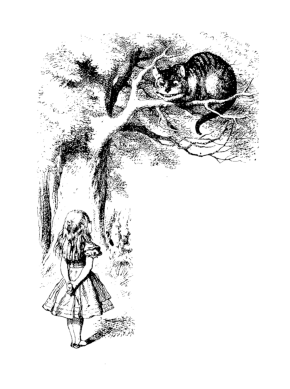

In [30]:
import cv2

# extract image & change pixel range to [0, 1]
img = cv2.imread("compression_image.gif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float64) / 255.0

# display original img
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

# 2B: Code & Answers

All images are saved in the svd_images folder, and the k=150 drawing is shown in the notebook.

In [31]:
# import
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

def get_approximation(image, k):
    if(k >= min(len(img), len(img[0]))):
        U, S, V_T = np.linalg.svd(image, full_matrices=False)
    else:
        U, S, V_T = svds(image, k=k) #ascending order so we need to reverse
        
    U = U[:, ::-1] #reverse columns
    S = S[::-1] #reverse array
    V_T = V_T[::-1, :] #reverse rows

    approximation = U @ np.diag(S) @ V_T

    return approximation

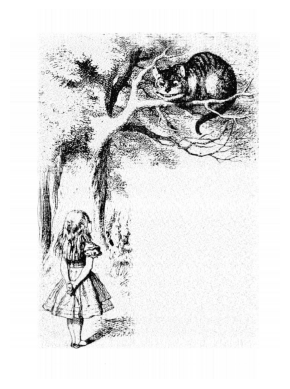

In [32]:
k_vals = [1, 3, 10, 20, 50, 100, 150, 200, 400, 800, 1170]

for k in k_vals:
    approx = get_approximation(img, k)
    approx = np.clip(approx, 0, 1)

    plt.imshow(approx, cmap="gray")
    plt.axis("off")
    plt.savefig(f"svd_images/k{k}-svd.png")
    if(k == 150):
        plt.show()
    plt.close()

# 2C: Code & Answers

We stopped at 1170, because the SVD creates a matrix with dimensions of `A x B`, where `A` represents the largest edge of the image (in this case, it is 1600), and B represents the value of k. Since the image is 1600px by 1170px, The maximum value of `B` must be 1170, since we cannot capture any more information than the 1170 horizontal pixels.

# 2D: Code & Answers

In [33]:
row, col, k = 1600, 1170, 150
U_memory = row * k
sigma_memory = k
V_T_memory = k * col

efficient_memory = U_memory + sigma_memory + V_T_memory
naive_memory = row * col

print(f"Efficient Memory: {efficient_memory}")
print(f"Naive Memory: {naive_memory}")
print(f"Efficient memory is {naive_memory - efficient_memory} units of memory smaller")
print(f"Efficient memory is {naive_memory / efficient_memory} times smaller")

Efficient Memory: 415650
Naive Memory: 1872000
Efficient memory is 1456350 units of memory smaller
Efficient memory is 4.503789245759654 times smaller
